Image size: (3816, 1842), mode: RGBA, format: PNG
Image shape: (1842, 3816, 4), dtype: uint8


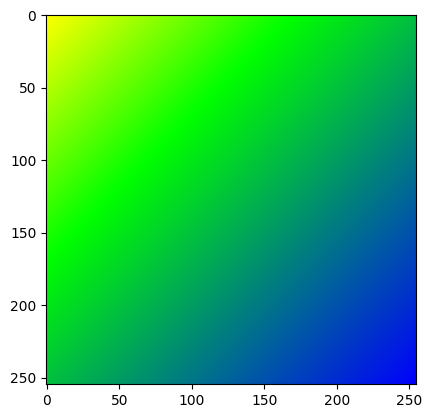

In [18]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 读取并显示图片
img = Image.open('figures/14_stokes.png')
print(f"Image size: {img.size}, mode: {img.mode}, format: {img.format}")
img_np = np.array(img)
print(f"Image shape: {img_np.shape}, dtype: {img_np.dtype}")

# 黄绿蓝渐变色（沿对角方向：黄→绿→蓝，各占约1/3）
width, height = 255, 255
x = np.arange(width, dtype=np.float32)
y = np.arange(height, dtype=np.float32)
xx, yy = np.meshgrid(x, y)

diag = (xx + yy) / (width + height)  # 0~1 对角方向
p = 1/3   # 过渡点位置（黄→绿在1/3，绿→蓝在2/3附近）

r = np.clip(255 * (1 - diag / p), 0, 255).astype(np.uint8)                        # 黄→绿：255→0
g = np.clip(255 * (1 - np.maximum(diag - p, 0) / (1 - p)), 0, 255).astype(np.uint8) # 保持255→降至0
b = np.clip(255 * (np.maximum(diag - p, 0) / (1 - p)), 0, 255).astype(np.uint8)     # 0→上升→255

arr = np.stack([r, g, b], axis=2)
img2 = Image.fromarray(arr)
plt.imshow(img2)
plt.axis('on')
img2.save('gradient.png')

## 图片的形态学操作

形态学操作是图像处理中基于形状的一系列操作，通常用于二值图像或灰度图像。核心概念是用**结构元素（Kernel）**在图像上滑动，进行集合运算。

### 常用操作

| 操作 | 函数 | 说明 |
|------|------|------|
| **腐蚀 (Erosion)** | `cv2.erode()` | 前景边界向内收缩，消除小的白色噪点 |
| **膨胀 (Dilation)** | `cv2.dilate()` | 前景边界向外扩张，填充物体内部空洞 |
| **开运算 (Opening)** | `cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)` | 先腐蚀后膨胀 → 去噪点、断开狭小连接 |
| **闭运算 (Closing)** | `cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)` | 先膨胀后腐蚀 → 填充小孔、连接断裂 |
| **形态学梯度** | `cv2.MORPH_GRADIENT` | 膨胀图−腐蚀图 → 提取物体边缘 |
| **顶帽 (Top Hat)** | `cv2.MORPH_TOPHAT` | 原图−开运算 → 提取亮色噪点 |
| **黑帽 (Black Hat)** | `cv2.MORPH_BLACKHAT` | 闭运算−原图 → 提取暗色噪点 |

### 结构元素

```python
import cv2
import numpy as np

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))   # 矩形
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)) # 椭圆形
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))   # 十字形
```

### 示例

```python
# 腐蚀与膨胀
eroded = cv2.erode(img, kernel, iterations=1)
dilated = cv2.dilate(img, kernel, iterations=1)

# 开运算与闭运算
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
```

> **注意**：形态学操作需 `opencv-python` 库，可通过 `pip install opencv-python` 安装。PIL 没有直接对应的形态学操作函数，但可以通过 `from PIL import ImageFilter` 中的 `ImageFilter.MinFilter` / `MaxFilter` 模拟简单的腐蚀/膨胀。

gradient.png size: (255, 255), shape: (255, 255, 3)


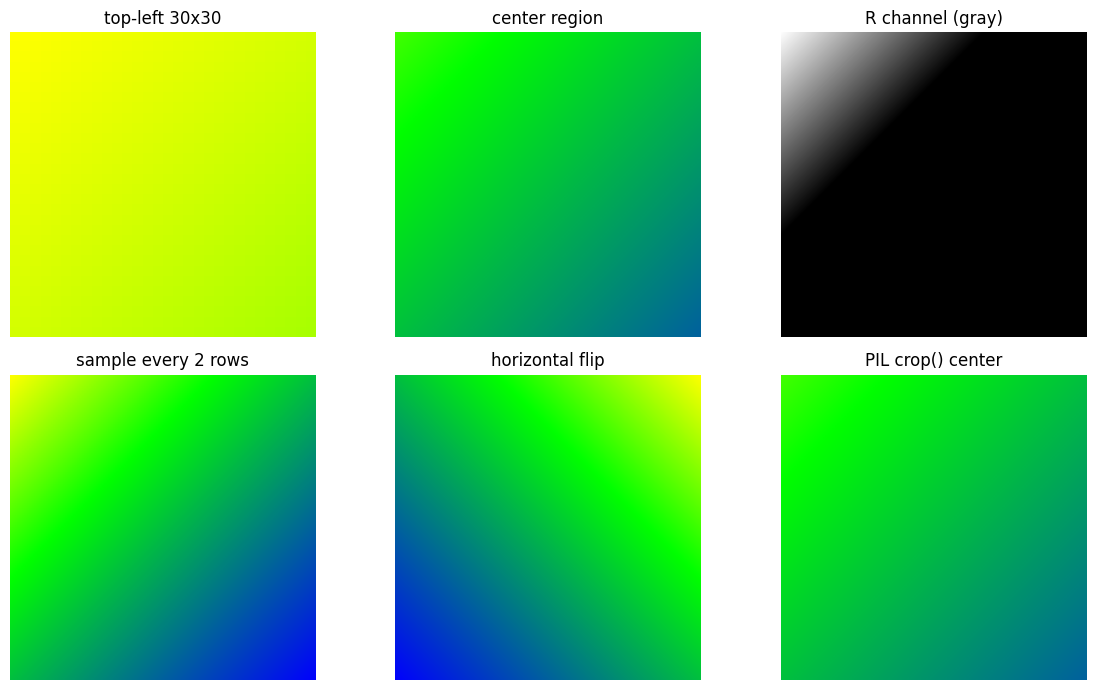

In [21]:
# 图片切片演示（使用 gradient.png）

img_grad = Image.open('gradient.png')
img_grad_np = np.array(img_grad)
print(f"gradient.png size: {img_grad.size}, shape: {img_grad_np.shape}")

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# 1. 裁剪左上角 30×30 区域（数组切片）
patch1 = img_grad_np[0:30, 0:30]
axes[0, 0].imshow(patch1)
axes[0, 0].set_title('top-left 30x30')
axes[0, 0].axis('off')

# 2. 裁剪中央区域
h, w = img_grad_np.shape[:2]
center = img_grad_np[h//4:3*h//4, w//4:3*w//4]
axes[0, 1].imshow(center)
axes[0, 1].set_title('center region')
axes[0, 1].axis('off')

# 3. 提取红色通道
red = img_grad_np[:, :, 0]
axes[0, 2].imshow(red, cmap='gray')
axes[0, 2].set_title('R channel (gray)')
axes[0, 2].axis('off')

# 4. 隔行采样（缩小图片）
sampled = img_grad_np[::2, ::2]
axes[1, 0].imshow(sampled)
axes[1, 0].set_title(f'sample every 2 rows')
axes[1, 0].axis('off')

# 5. 左右翻转
flipped = img_grad_np[:, ::-1]
axes[1, 1].imshow(flipped)
axes[1, 1].set_title('horizontal flip')
axes[1, 1].axis('off')

# 6. PIL crop() 方式
patch_pil = img_grad.crop((w//4, h//4, 3*w//4, 3*h//4))
axes[1, 2].imshow(patch_pil)
axes[1, 2].set_title('PIL crop() center')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 批量将 images/ 中的图片缩放为 416×416，保存到 images_resized/
import os

input_dir = 'images'
output_dir = 'images_resized'
target_size = (416, 416)

# 创建输出文件夹
os.makedirs(output_dir, exist_ok=True)

# 获取所有图片文件
exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
files = [f for f in os.listdir(input_dir) if f.lower().endswith(exts)]
print(f"Found {len(files)} images in '{input_dir}/'")

for i, filename in enumerate(files, 1):
    img_path = os.path.join(input_dir, filename)
    img_i = Image.open(img_path)

    # 如果图片有 Alpha 通道（RGBA/PA），转为 RGB（JPEG 不支持 RGBA）
    if img_i.mode in ('RGBA', 'PA', 'P'):
        img_i = img_i.convert('RGB')

    # 缩放到 416×416
    img_resized = img_i.resize(target_size)

    # 保存到输出目录（不覆盖原文件）
    out_path = os.path.join(output_dir, filename)
    # 统一保存为 jpg 防止格式冲突
    if out_path.lower().endswith(('.png', '.bmp', '.tiff', '.webp')):
        out_path = os.path.splitext(out_path)[0] + '.jpg'
    img_resized.save(out_path)
    print(f"  [{i}/{len(files)}] {filename} -> {os.path.basename(out_path)}  ({img_resized.size[0]}x{img_resized.size[1]})")

print(f"\nDone! All {len(files)} images resized to {target_size[0]}x{target_size[1]}.")
print(f"Output folder: '{output_dir}/'")

Found 14 images in 'images/'
  [1/14] Abyssinian_1.jpg -> Abyssinian_1.jpg  (416x416)
  [2/14] Abyssinian_13.jpg -> Abyssinian_13.jpg  (416x416)
  [3/14] Abyssinian_14.jpg -> Abyssinian_14.jpg  (416x416)
  [4/14] Abyssinian_15.jpg -> Abyssinian_15.jpg  (416x416)
  [5/14] Abyssinian_16.jpg -> Abyssinian_16.jpg  (416x416)
  [6/14] Abyssinian_17.jpg -> Abyssinian_17.jpg  (416x416)
  [7/14] Abyssinian_18.jpg -> Abyssinian_18.jpg  (416x416)
  [8/14] Abyssinian_19.jpg -> Abyssinian_19.jpg  (416x416)
  [9/14] Abyssinian_2.jpg -> Abyssinian_2.jpg  (416x416)
  [10/14] Abyssinian_3.jpg -> Abyssinian_3.jpg  (416x416)
  [11/14] Abyssinian_4.jpg -> Abyssinian_4.jpg  (416x416)
  [12/14] Abyssinian_5.jpg -> Abyssinian_5.jpg  (416x416)
  [13/14] Abyssinian_6.jpg -> Abyssinian_6.jpg  (416x416)
  [14/14] Abyssinian_7.jpg -> Abyssinian_7.jpg  (416x416)

Done! All 14 images resized to 416x416.
Output folder: 'images_resized/'


Original: mode=RGB, size=(255, 255)


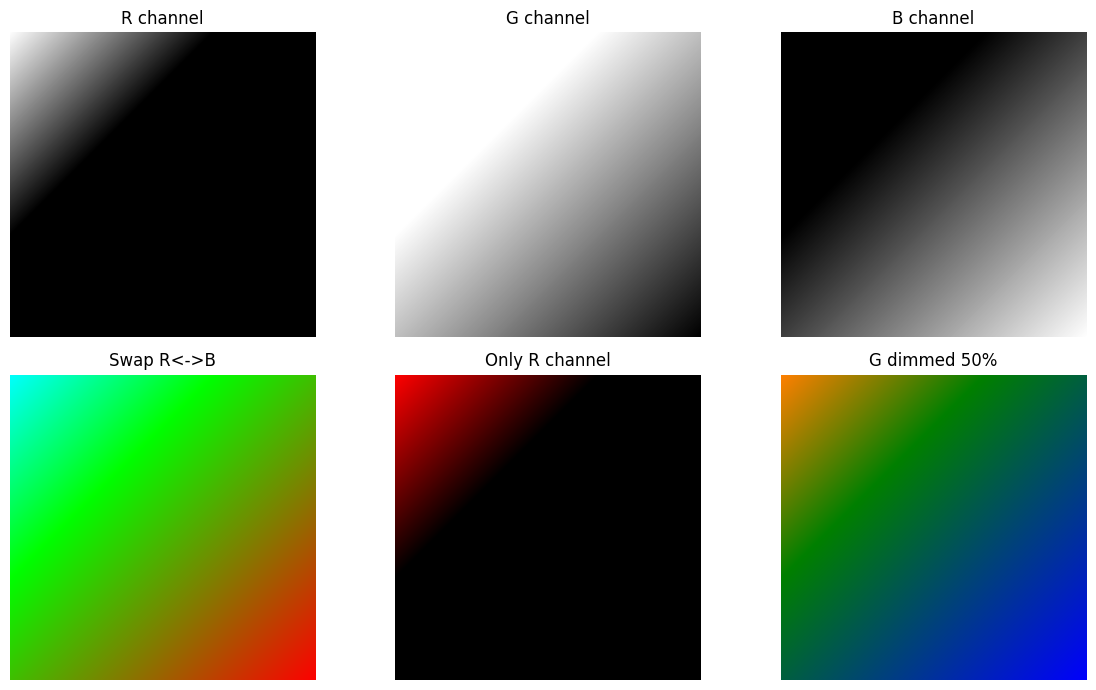

Saved: gradient_R.jpg, gradient_G.jpg, gradient_B.jpg


In [22]:
# 图像通道分离与合并（以 gradient.png 为例）

img = Image.open('gradient.png')
print(f"Original: mode={img.mode}, size={img.size}")

# ============ 方法一：PIL split/merge ============
r_pil, g_pil, b_pil = img.split()

# 分别显示三个通道
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

axes[0, 0].imshow(r_pil, cmap='gray')
axes[0, 0].set_title('R channel')
axes[0, 0].axis('off')

axes[0, 1].imshow(g_pil, cmap='gray')
axes[0, 1].set_title('G channel')
axes[0, 1].axis('off')

axes[0, 2].imshow(b_pil, cmap='gray')
axes[0, 2].set_title('B channel')
axes[0, 2].axis('off')

# ============ 方法二：NumPy 数组切片 ============
arr = np.array(img)
r_np, g_np, b_np = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]

# ============ 通道合并 ============
# 1. 调换通道顺序 R<->B
swapped = np.stack([b_np, g_np, r_np], axis=2)
img_swapped = Image.fromarray(swapped)
axes[1, 0].imshow(img_swapped)
axes[1, 0].set_title('Swap R<->B')
axes[1, 0].axis('off')

# 2. 单通道保留（红色通道+绿色调零）
only_r = np.stack([r_np, np.zeros_like(g_np), np.zeros_like(b_np)], axis=2)
axes[1, 1].imshow(only_r)
axes[1, 1].set_title('Only R channel')
axes[1, 1].axis('off')

# 3. 合并：调整通道亮度
brighter = np.stack([r_np, (g_np * 0.5).astype(np.uint8), b_np], axis=2)
axes[1, 2].imshow(brighter)
axes[1, 2].set_title('G dimmed 50%')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# 保存分离后的单通道图（作为灰度图）
r_pil.save('gradient_R.jpg')
g_pil.save('gradient_G.jpg')
b_pil.save('gradient_B.jpg')
print("Saved: gradient_R.jpg, gradient_G.jpg, gradient_B.jpg")

Image size: 255x255
Each cell: 85x85


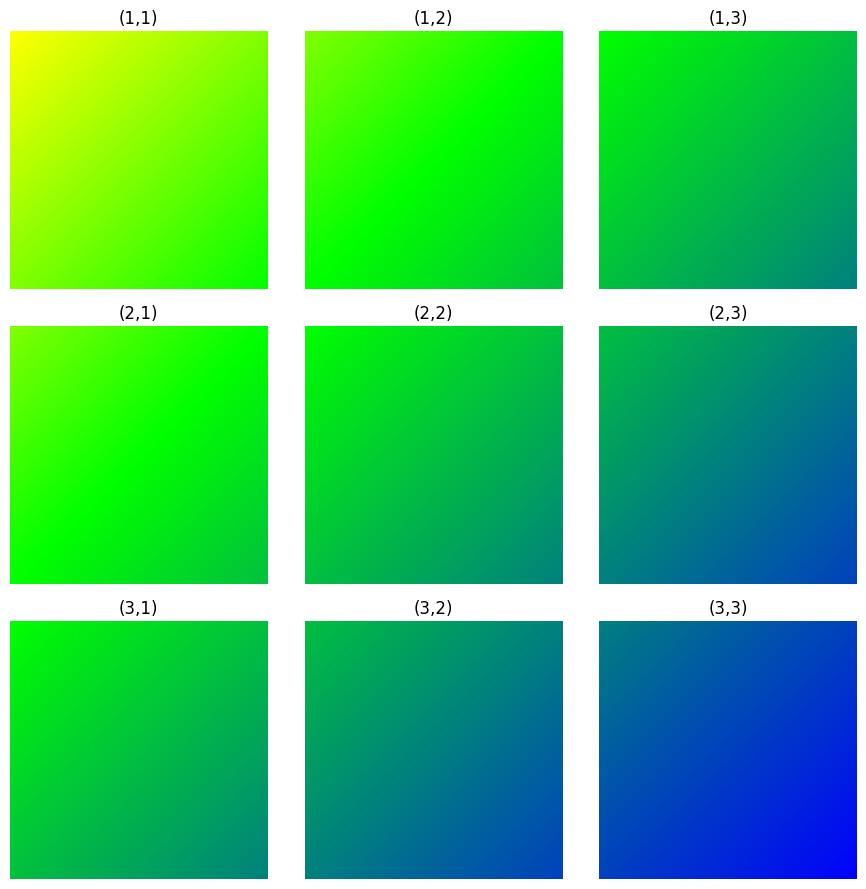

In [23]:
# 将 gradient.png 拆分成九宫格

img = Image.open('gradient.png')
arr = np.array(img)
h, w = arr.shape[:2]
print(f"Image size: {w}x{h}")

# 每个格子的大小
grid_h, grid_w = h // 3, w // 3
print(f"Each cell: {grid_w}x{grid_h}")

fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for row in range(3):
    for col in range(3):
        y_start = row * grid_h
        y_end = (row + 1) * grid_h if row < 2 else h
        x_start = col * grid_w
        x_end = (col + 1) * grid_w if col < 2 else w

        patch = arr[y_start:y_end, x_start:x_end]
        axes[row, col].imshow(patch)
        axes[row, col].set_title(f'({row+1},{col+1})')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

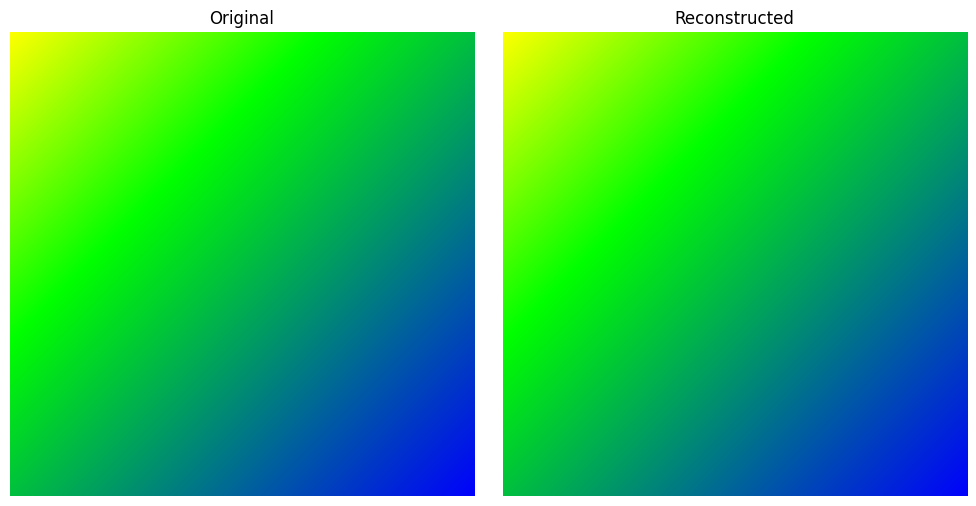

Original shape:     (255, 255, 3)
Reconstructed shape: (255, 255, 3)
Match: True


In [24]:
# 将九宫格重新拼回原图

img = Image.open('gradient.png')
arr = np.array(img)
h, w = arr.shape[:2]
grid_h, grid_w = h // 3, w // 3

# 先拆成 3×3 的小块
patches = []
for row in range(3):
    row_patches = []
    for col in range(3):
        y_start = row * grid_h
        y_end = (row + 1) * grid_h if row < 2 else h
        x_start = col * grid_w
        x_end = (col + 1) * grid_w if col < 2 else w
        row_patches.append(arr[y_start:y_end, x_start:x_end])
    patches.append(row_patches)

# 拼回去：每行水平拼接，再将三行垂直拼接
row1 = np.concatenate(patches[0], axis=1)  # 水平拼接第一行
row2 = np.concatenate(patches[1], axis=1)  # 水平拼接第二行
row3 = np.concatenate(patches[2], axis=1)  # 水平拼接第三行
reconstructed = np.concatenate([row1, row2, row3], axis=0)  # 垂直拼接三行

# 对比原图和拼接结果
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(arr)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(reconstructed)
axes[1].set_title('Reconstructed')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 验证是否完全一致
print(f"Original shape:     {arr.shape}")
print(f"Reconstructed shape: {reconstructed.shape}")
print(f"Match: {np.array_equal(arr, reconstructed)}")

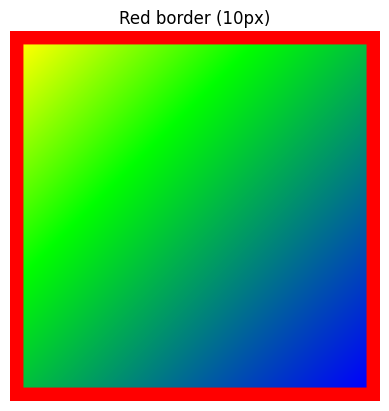

Saved: gradient_border.png (275x275)


In [25]:
# 给 gradient.png 添加红色边框

img = Image.open('gradient.png')
arr = np.array(img)
h, w = arr.shape[:2]

border = 10  # 边框宽度（像素）
red = [255, 0, 0]  # RGB 红色

# 方法：创建一个更大的纯红画布，把原图贴中间
canvas = np.full((h + 2*border, w + 2*border, 3), red, dtype=np.uint8)
canvas[border:border+h, border:border+w] = arr

img_border = Image.fromarray(canvas)
plt.imshow(img_border)
plt.axis('off')
plt.title(f'Red border ({border}px)')
plt.show()
img_border.save('gradient_border.png')
print(f"Saved: gradient_border.png ({canvas.shape[1]}x{canvas.shape[0]})")

Chosen: Abyssinian_15.jpg
Background size: 275x275
Pasted at: (107, 158)


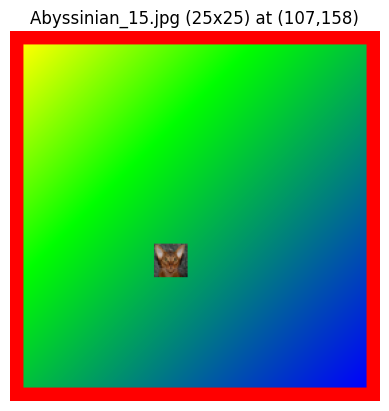

Saved: gradient_collage.png


In [52]:
# 从 images/ 随机选一张图片，缩放后贴到 gradient_border.png 上
import os
import random

# 获取 images/ 下所有图片
exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
img_files = [f for f in os.listdir('images') if f.lower().endswith(exts)]

# 随机选一张
chosen = random.choice(img_files)
print(f"Chosen: {chosen}")

# 打开并缩放到 25×25
thumb = Image.open(os.path.join('images', chosen)).resize((25, 25))

# 打开带边框的底图
bg = Image.open('gradient_border.png')
bg_w, bg_h = bg.size
print(f"Background size: {bg_w}x{bg_h}")

# 随机位置（确保 25×25 不超出边界）
x = random.randint(0, bg_w - 25)
y = random.randint(0, bg_h - 25)

# 粘贴（如果 thumb 有透明通道则作为遮罩，否则直接覆盖）
if thumb.mode == 'RGBA':
    bg.paste(thumb, (x, y), thumb)
else:
    bg.paste(thumb, (x, y))

print(f"Pasted at: ({x}, {y})")

plt.imshow(bg)
plt.axis('off')
plt.title(f'{chosen} (25x25) at ({x},{y})')
plt.show()
bg.save('gradient_collage.png')
print("Saved: gradient_collage.png")

Loaded 6 pairs:
  01.png -> 01.png  box=[100, 120, 200, 220]
  02.png -> 02.png  box=[150, 100, 250, 200]
  03.png -> 03.png  box=[120, 200, 220, 300]
  04.png -> 04.png  box=[130, 100, 230, 200]
  05.png -> 05.png  box=[110, 200, 210, 300]
  06.png -> 06.png  box=[100, 110, 200, 210]

Randomly chosen: 03.png -> 03.png
  xhr size: (690, 976), bg size: (1684, 945)
  resized xhr to: (100, 100)
  pasted at: (120, 200) (from labels.txt)


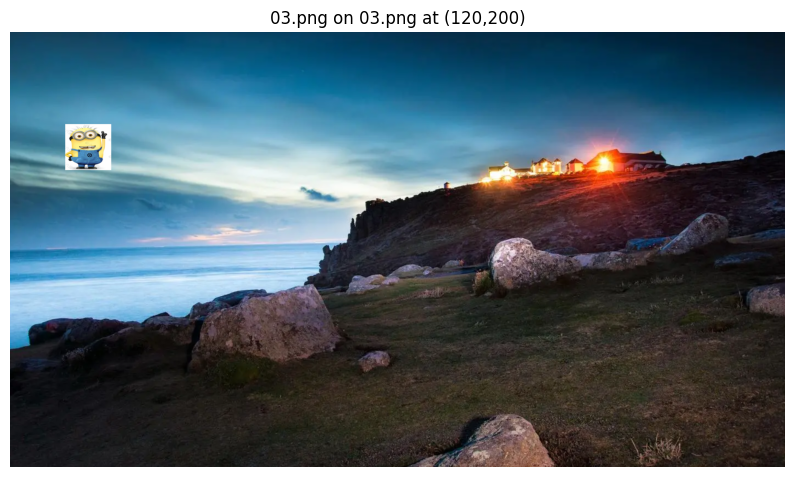

Saved: minion_collage.png


In [63]:
# 读取 data/labels.txt，将小黄人随机粘贴到背景图上

import json
import random

# 1. 读取 labels.txt
pairs = []
with open('data/labels.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('\t')
        xhr_name = parts[0]
        info_list = json.loads(parts[1])  # 解析为列表 [{"img": ..., "point": [...]}]
        info = info_list[0]                # 取列表中的第一个字典
        bg_name = info['img']
        point = info['point']  # [x1, y1, x2, y2]
        pairs.append((xhr_name, bg_name, point))

print(f"Loaded {len(pairs)} pairs:")
for xhr_name, bg_name, pt in pairs:
    print(f"  {xhr_name} -> {bg_name}  box={pt}")

# 2. 随机选取一组并粘贴
xhr_name, bg_name, box = random.choice(pairs)
print(f"\nRandomly chosen: {xhr_name} -> {bg_name}")

# 打开图片
xhr = Image.open(f'data/xhr_imgs/{xhr_name}')
bg = Image.open(f'data/bg_imgs/{bg_name}').convert('RGB')
print(f"  xhr size: {xhr.size}, bg size: {bg.size}")

# 转 RGBA（保留透明通道便于粘贴）
if xhr.mode != 'RGBA':
    xhr = xhr.convert('RGBA')

# 根据标注框计算缩放尺寸并 resize
box_w, box_h = box[2] - box[0], box[3] - box[1]
xhr_resized = xhr.resize((box_w, box_h))
print(f"  resized xhr to: {xhr_resized.size}")

paste_x, paste_y = box[0], box[1]
print(f"  pasted at: ({paste_x}, {paste_y}) (from labels.txt)")

bg.paste(xhr_resized, (paste_x, paste_y), xhr_resized)

plt.figure(figsize=(10, 7))
plt.imshow(bg)
plt.axis('off')
plt.title(f'{xhr_name} on {bg_name} at ({paste_x},{paste_y})')
plt.show()
bg.save('minion_collage.png')
print("Saved: minion_collage.png")